In [1]:
import numpy as np
import matplotlib.pyplot as plt

# XTCAV classes
from xtcav_dark_reference import XTCAVDarkReference
from xtcav_lasing_off import XTCAVLasingOffReference
from xtcav_lasing_on import XTCAVLasingOnReconstruction

# Data access
import psana
get_datasource = lambda runnum: psana.DataSource(f"exp=cxil1037623:run={runnum}:idx")

In [ ]:
# Fails
data_source = get_datasource(152)

In [ ]:
# Succeeds
data_source = get_datasource(153)

In [ ]:
# Fails
data_source = get_datasource(154)

In [ ]:
# Fails
data_source = get_datasource(155)

In [ ]:
# Fails
data_source = get_datasource(156)

In [ ]:
# Fails
data_source = get_datasource(157)

In [ ]:
# Fails
data_source = get_datasource(158)

In [ ]:
# Fails
data_source = get_datasource(159)

In [ ]:
# ??
data_source = get_datasource(160)

In [ ]:
# ??
data_source = get_datasource(161)

In [3]:
import signal,time

class TimeoutException(Exception):
    pass

def timeout_handler(signum, frame):
    raise TimeoutException

def crappy_function():
    time.sleep(5)
    print('Dun dun dun dun DUNNNN')

try:
    signal.signal(signal.SIGALRM, timeout_handler)
    signal.alarm(2)
    crappy_function()
except TimeoutException:
    print("Function timed out!")
finally:
    signal.alarm(0)

Function timed out!


In [ ]:
import signal
from tqdm.auto import tqdm


# Parameters
max_allowed_time = 10                     # Let datasets try to load for this long
datasets = np.arange(152,172,dtype=int)   # Try these datasets from L10376


# Data loading test utilities
def load_S3DF_data_with_psana(runnum):
    return psana.DataSource(f"exp=cxil1037623:run={runnum}:idx")
class TimeoutException(Exception):
    pass
def timeout_handler(signum, frame):
    raise TimeoutException

# Loop over datasets, trying to load each
successes = []
failures = []
for runnum in tqdm(datasets,desc="Testing psana loading on S3DF"):
    try:
        signal.signal(signal.SIGALRM, timeout_handler)
        signal.alarm(2)                   # set the timeout alarm
        load_S3DF_data_with_psana(runnum)
    except TimeoutException:
        failures.append( runnum )
        print(f"FAILED to load data run {runnum}")
    finally:
        successes.append( runnum )
        print(f"SUCCEEDED loading data run {runnum}")
        signal.alarm(0)                   # turn the alarm off

Testing psana loading on S3DF:   0%|          | 0/20 [00:00<?, ?it/s]

# Lasing-off reference

In [ ]:
# Create object
xtoff = XTCAVLasingOffReference(
    get_datasource(runnum_lasingoff),
    shots_per_group = shotsPerGroup_lasingOff_profiles,
    fov = fov,
    dark_reference = xtdr,
    n_pulses = n_pulses,
)

# Examine the first event
i,j,evt = next(xtoff.shot_iterator)
xtoff.set_current_event(evt)
xtoff.show_current_frame(
    vrange=(0,350),
    bins=np.linspace(0,1000,100),
)

In [ ]:
# Examine a few more events

n_shots_show = 3

print(f"Looping through the next {n_shots_show} 'ok' events...")
for idx,(i,j,evt) in enumerate(xtoff.shot_iterator):
    print(f"Showing 'ok' shot #{i+1} at time index {j}:")

    # Get & show event
    xtoff.set_current_event(evt)
    xtoff.show_current_frame()

    # continue?
    if idx>=n_shots_show-1:
        break

In [ ]:
# Background subtraction

# # Set dark ref
# xtoff.set_darkreference(xtdr)

# Examine dark ref subtracted data
xtoff.reset_shot_iterator()
n_shots_show = 3
print(f"Looping through the first {n_shots_show} 'ok' events...")
for idx,(i,j,evt) in enumerate(xtoff.shot_iterator):
    print(f"Showing 'ok' shot #{i+1} at time index {j}:")

    # Get & show event
    xtoff.set_current_event(evt)
    xtoff.show_current_frame(preprocess='bksb')

    # continue?
    if idx>=n_shots_show-1:
        break

In [ ]:
# Denoise

xtoff.show_frame(
    frame = xtoff.get_frame_denoised_current(
        nstd=1,                              # auto updates default params
        close=2
    ),
    vrange=(0,6e-4),                         # update intensity display range;
    bins=np.linspace(0,1e-3,100),            # denoising also normalizes total image intensity to 1
)

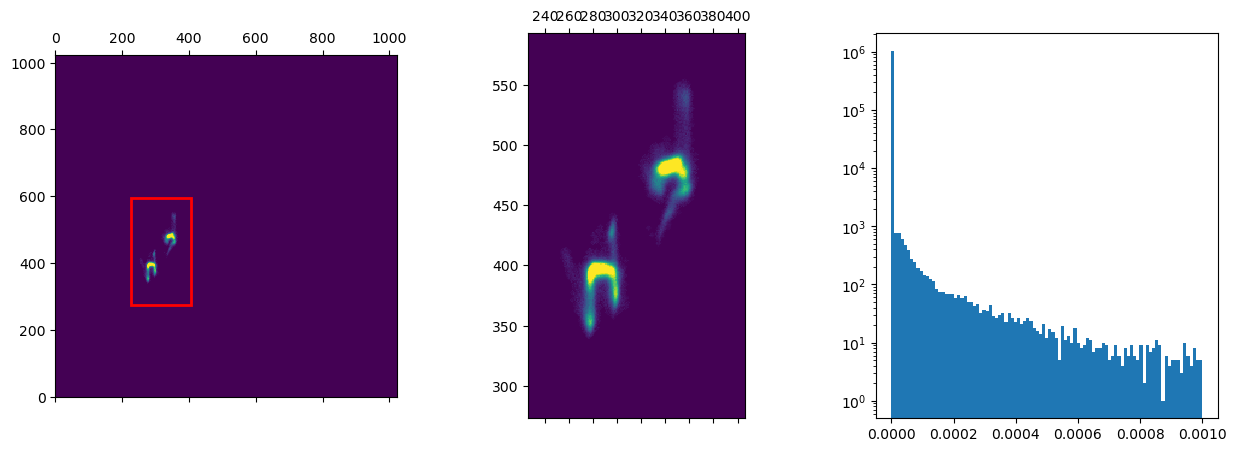

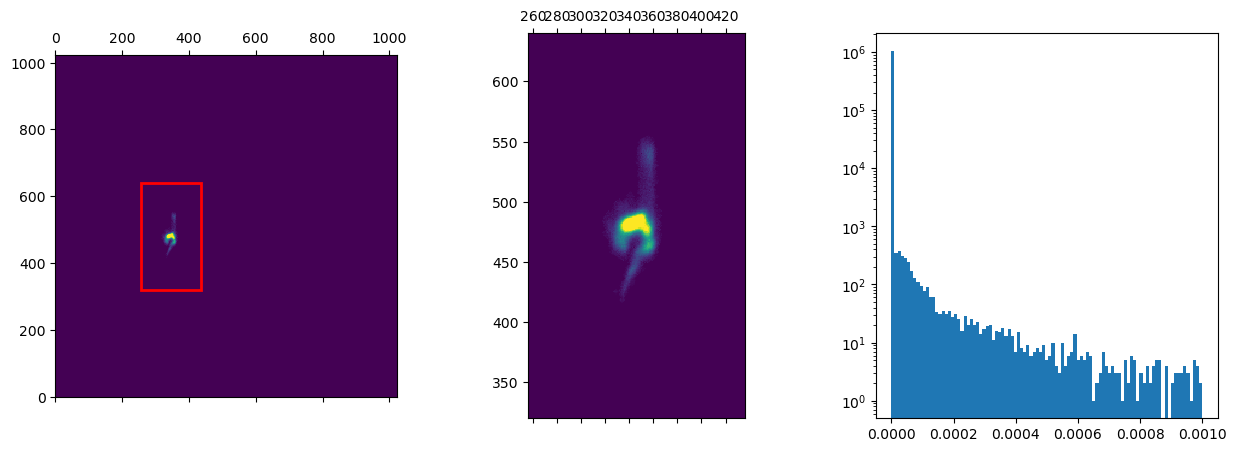

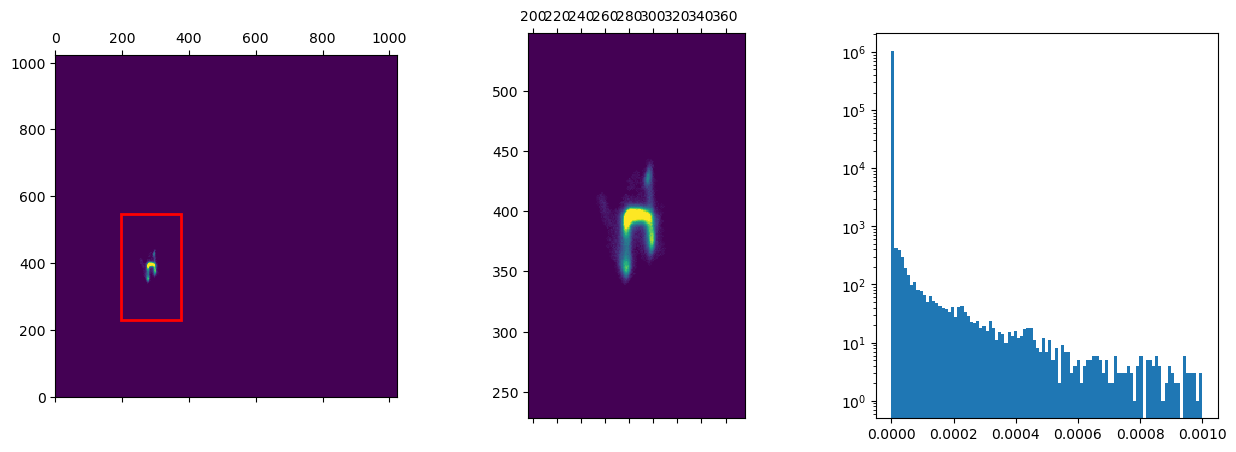

In [9]:
# Split images

# Get a denoised frame & split its pulses
im = xtoff.get_frame_denoised_current()
ims,ok = xtoff.split_frame(im)
assert(ok), "Failed to split image frame"

# Show
for image in (im,ims[0],ims[1]):   # Original image, pulse 1, and pulse 2
    xtoff.show_frame(image)

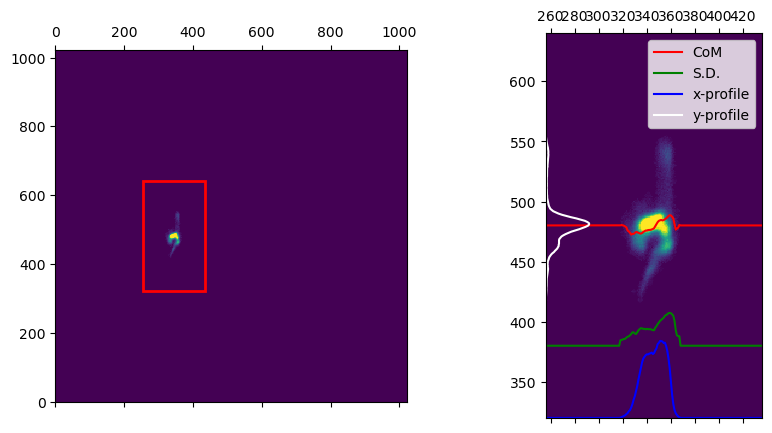

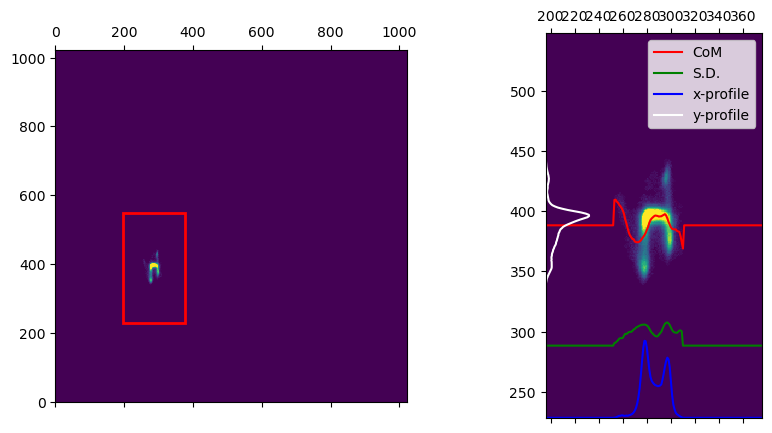

In [10]:
# Get image statistics

frame1,frame2 = ims[0],ims[1]
imageStats1 = xtoff.get_pulse_statistics(frame1)
imageStats2 = xtoff.get_pulse_statistics(frame2)

# Show
xtoff.show_frame_statistics(
    frame1,
    imageStats1,
)
xtoff.show_frame_statistics(
    frame2,
    imageStats2,
)

## Get full lasing-off data run image statistics

In [11]:
xtoff.get_shot_by_shot_statistics()

Calculating shot-by-shot statistics...:   0%|          | 0/5246 [00:00<?, ?it/s]

/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:1380: UserWarning: Hardcoded calibrations are not yet calculated - returning uncalibrated axes!
  warnings.warn("Hardcoded calibrations are not yet calculated - returning uncalibrated axes!")
/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:1526: RuntimeWarning: invalid value encountered in scalar divide
  x = np.sum(xx*ar)/m
/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:1527: RuntimeWarning: invalid value encountered in scalar divide
  y = np.sum(yy*ar)/m
/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:1052: RuntimeWarning: invalid value encountered in divide
  ans /= np.sum(ans)


All 5246 shots have been traversed.
Resetting the shot iterator.
Done. Calculated statistics for 4635 'good' shots.
Setting shot iterator to traverse good shots only.


-------------------------------
Showing usable shot #1:
-------------------------------


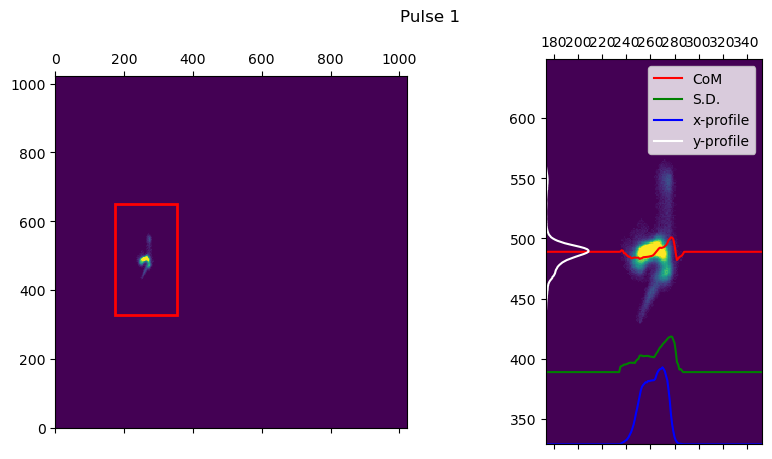

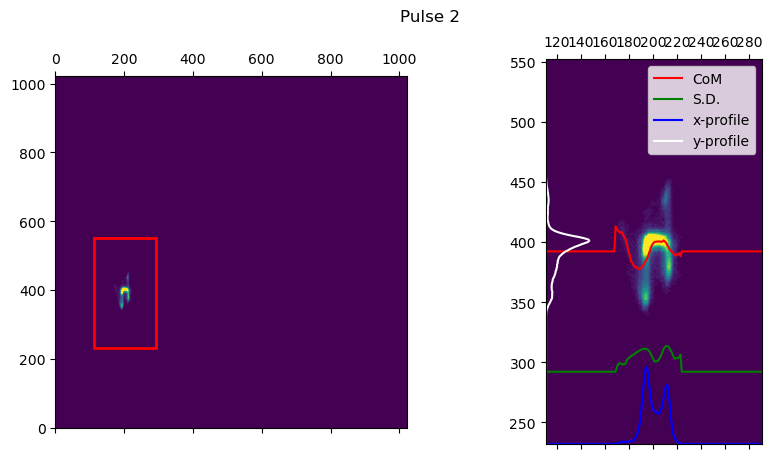

-------------------------------
Showing usable shot #1001:
-------------------------------


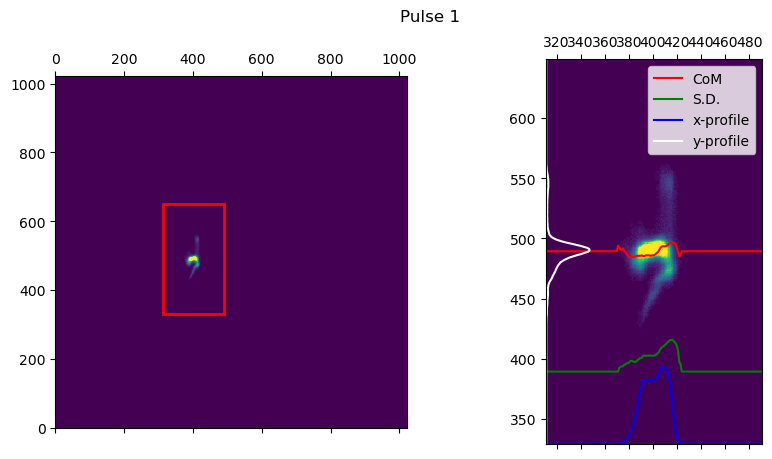

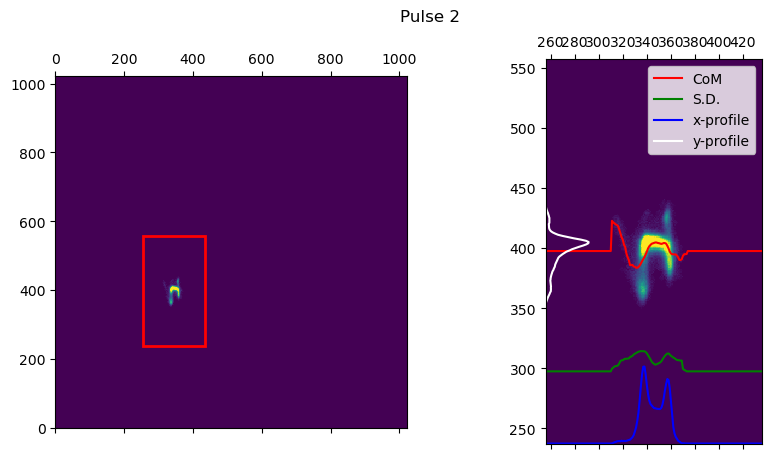

-------------------------------
Showing usable shot #2001:
-------------------------------


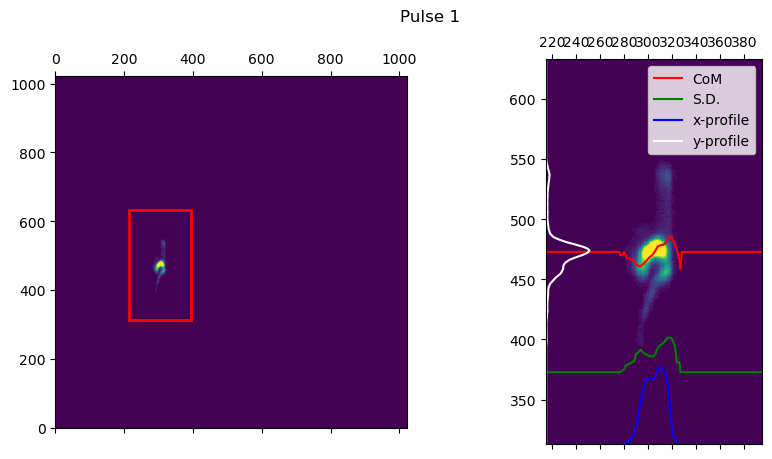

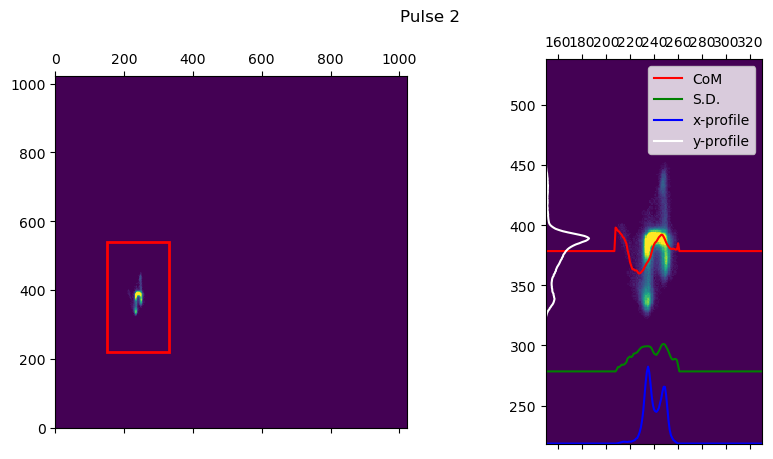

-------------------------------
Showing usable shot #3001:
-------------------------------


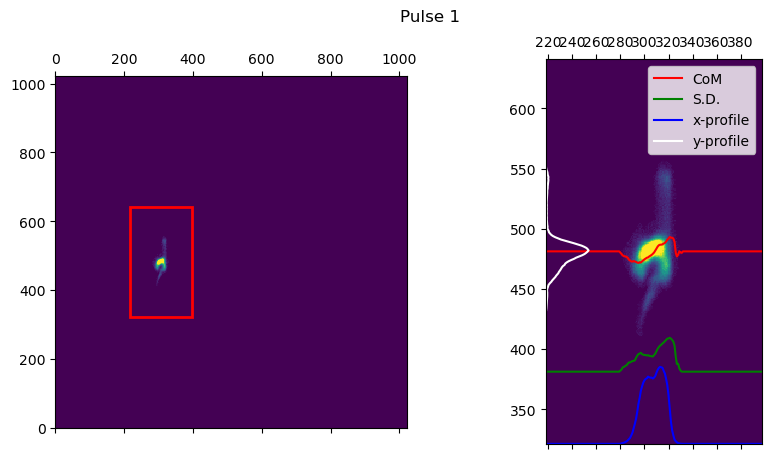

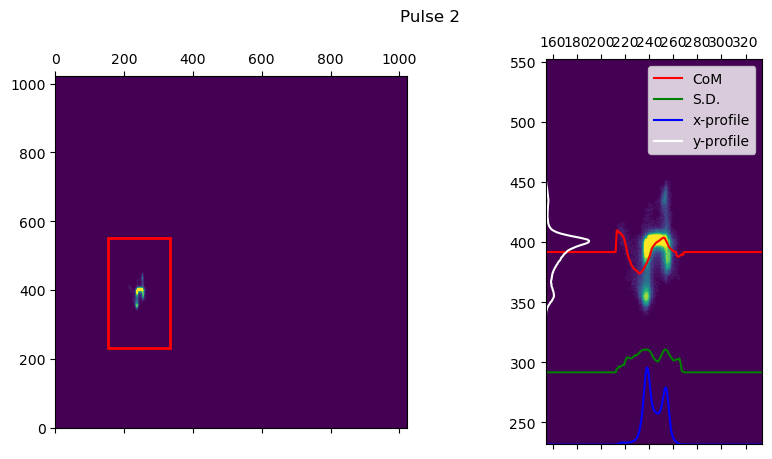

-------------------------------
Showing usable shot #4001:
-------------------------------


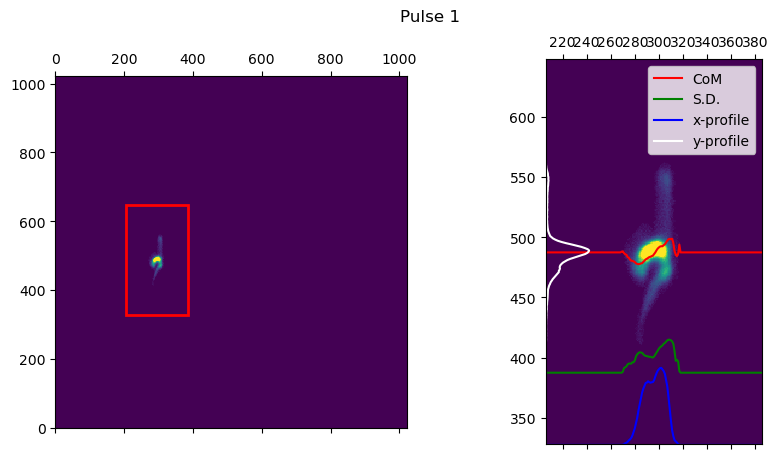

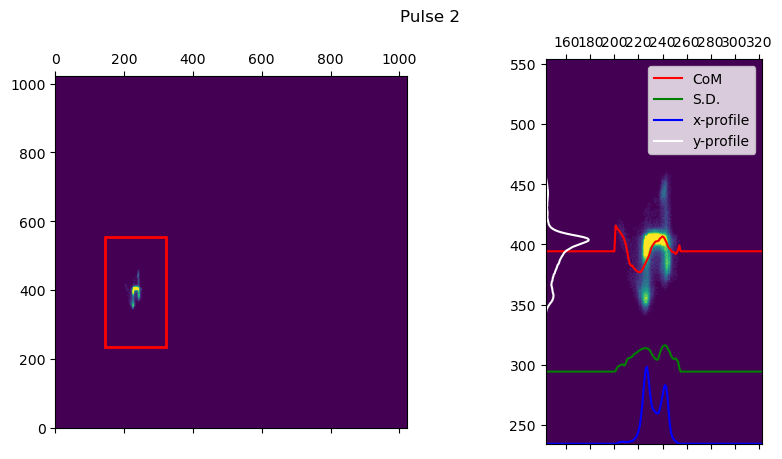

In [12]:
# Show a few shots & their pulse statistics

for i in [0,1000,2000,3000,4000]:       # select a few shots
    print("-------------------------------")
    print(f"Showing usable shot #{i+1}:")
    print("-------------------------------")
    xtoff.show_pulse_statistics( i )

## Get lasing-off average profiles

In [13]:
# Get lasing-off reference profiles

xtoff.calculate_reference_profiles()

Looping through the 2 pulses:   0%|          | 0/2 [00:00<?, ?it/s]

Interpolating XTCAV profiles:   0%|          | 0/4635 [00:00<?, ?it/s]

Forming 46 groups & calculating averages:   0%|          | 0/46 [00:00<?, ?it/s]

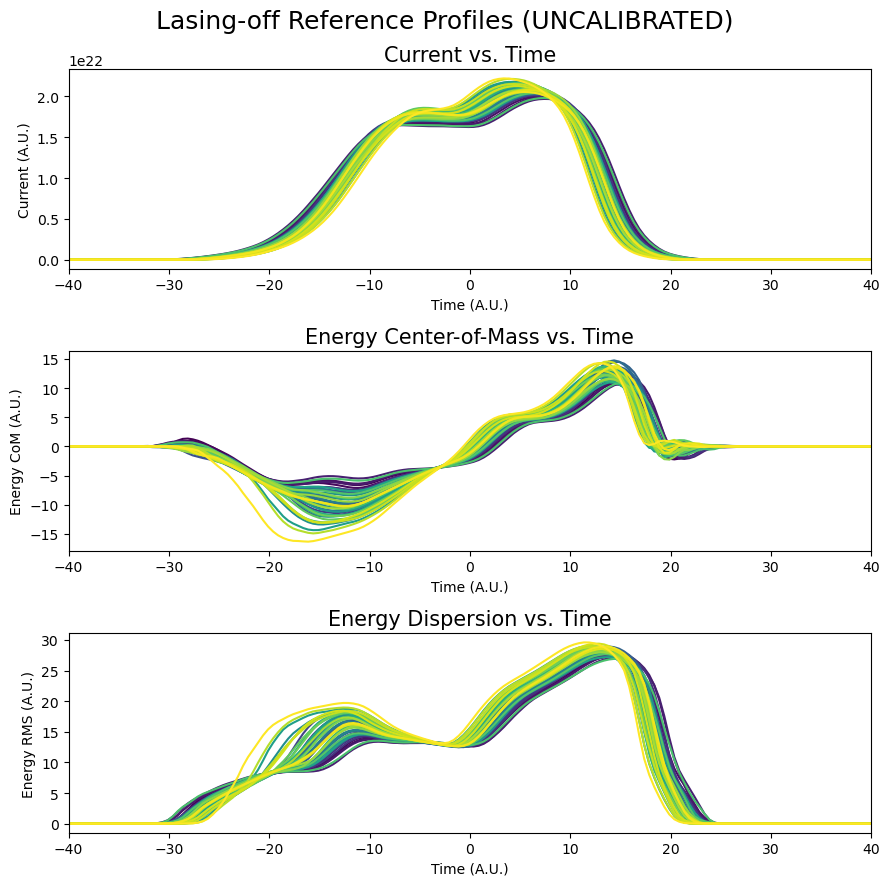

In [14]:
# Show reference profiles: 1'st pulse

xtoff.show_reference_profiles(
    idx_pulse=0,
    lims=[-40,40]
)

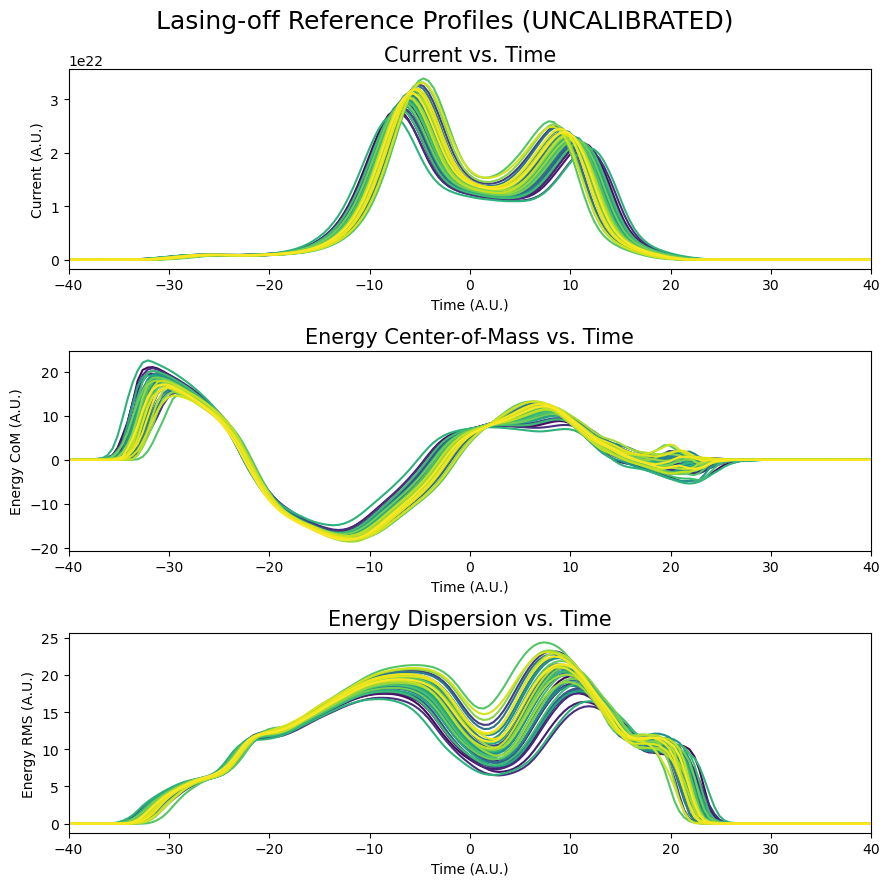

In [15]:
# Show reference profiles: 2'nd pulse

xtoff.show_reference_profiles(
    idx_pulse=1,
    lims=[-40,40]
)

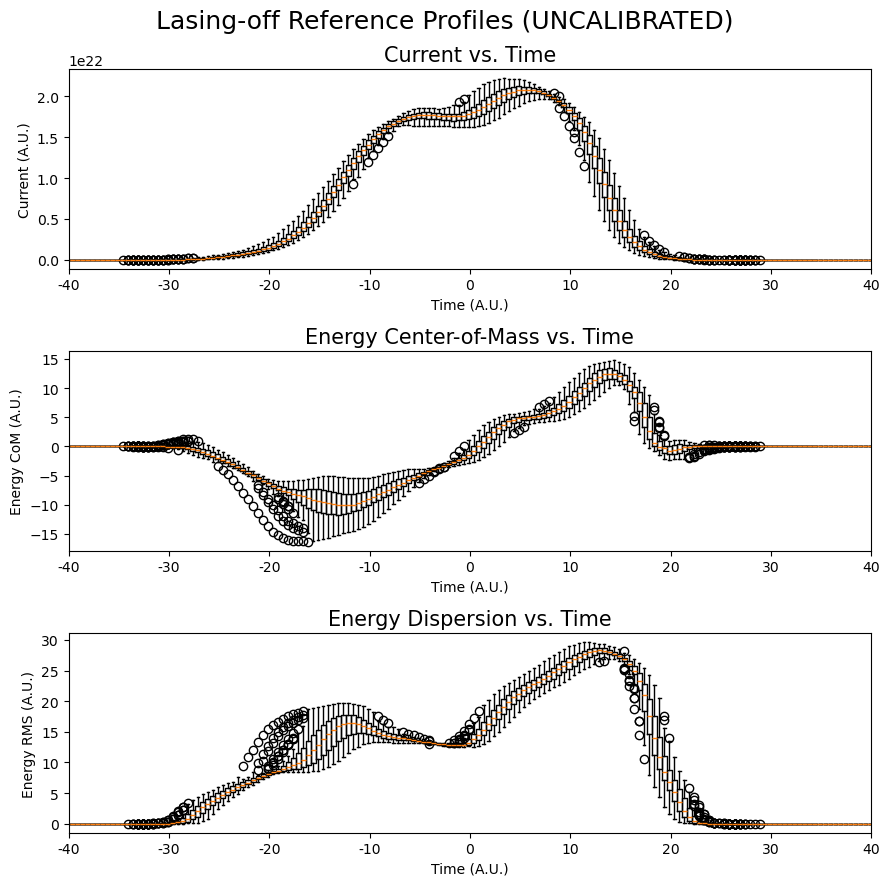

In [16]:
# Show reference profile boxplots: 1'st pulse

xtoff.show_reference_profiles_boxplots(
    idx_pulse=0,
    lims=[-40,40]
)

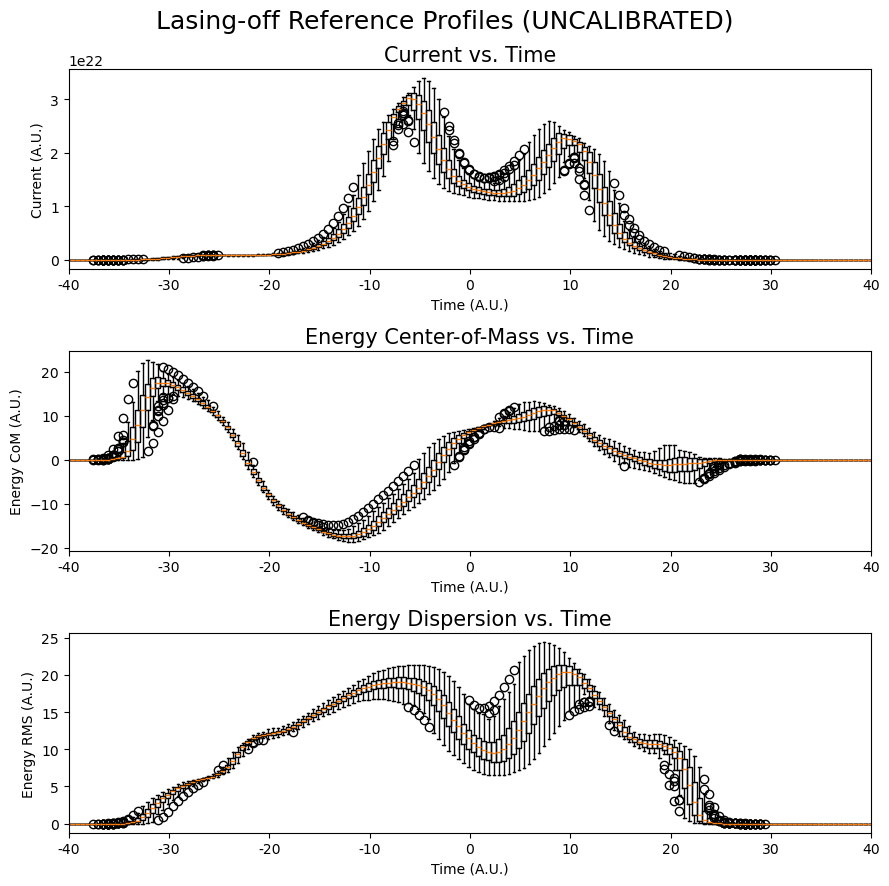

In [17]:
# Show reference profile boxplots: 2'nd pulse

xtoff.show_reference_profiles_boxplots(
    idx_pulse=1,
    lims=[-40,40]
)

# Lasing-on Reconstructions

Setting up data run times...
Done.


XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV
/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:171: UserWarning: Failed to find all global calibrations!
  warnings.warn('Failed to find all global calibrations!')


Setting data source types...:   0%|          | 0/50400 [00:00<?, ?it/s]

Data source types successfully set.
Electron beam source type is <class 'psana.Bld.BldDataEBeamV7'>
Gas detector source type is <class 'psana.Bld.BldDataFEEGasDetEnergyV1'>


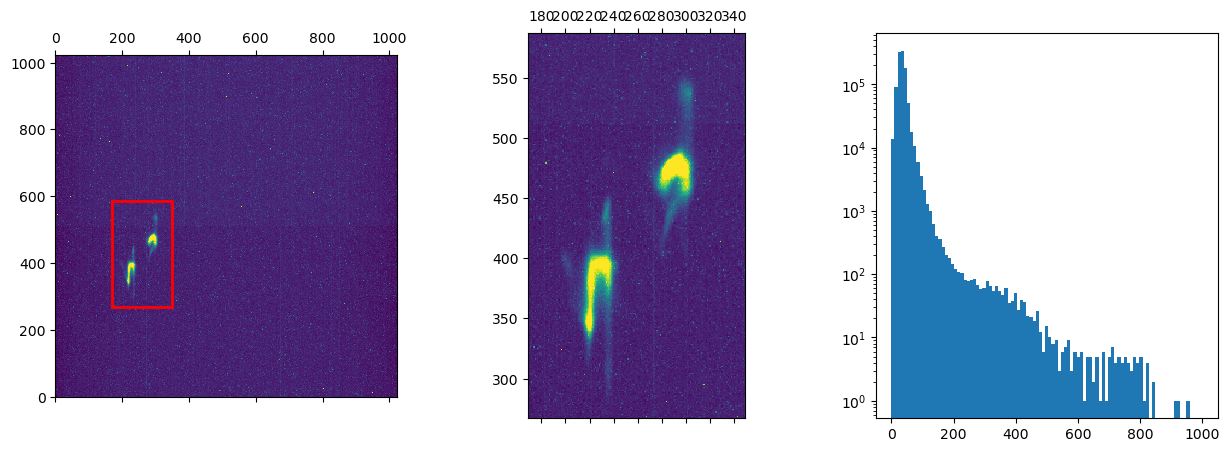

In [18]:
# Create object
xton = XTCAVLasingOnReconstruction(
    get_datasource(runnum_lasingon),
    fov = fov,
    dark_reference = xtdr,
    lasing_off = xtoff,
    n_pulses = n_pulses,
)

# Examine the first event
i,j,evt = next(xton.shot_iterator)
xton.set_current_event(evt)
xton.show_current_frame(
    vrange=(0,350),
    bins=np.linspace(0,1000,100),
)

Looping through the next 3 'ok' events...
Showing 'ok' shot #2 at time index 270:


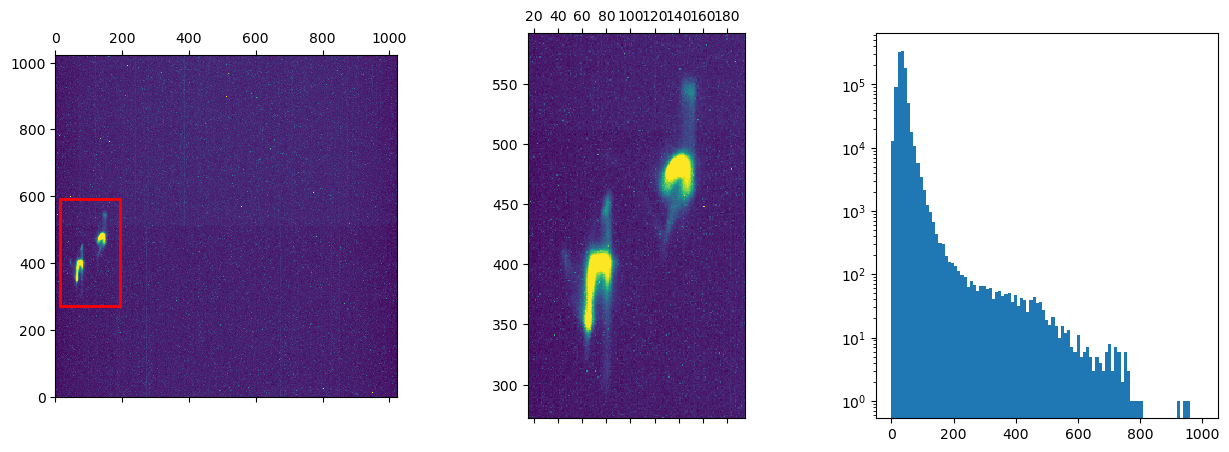

Showing 'ok' shot #3 at time index 271:


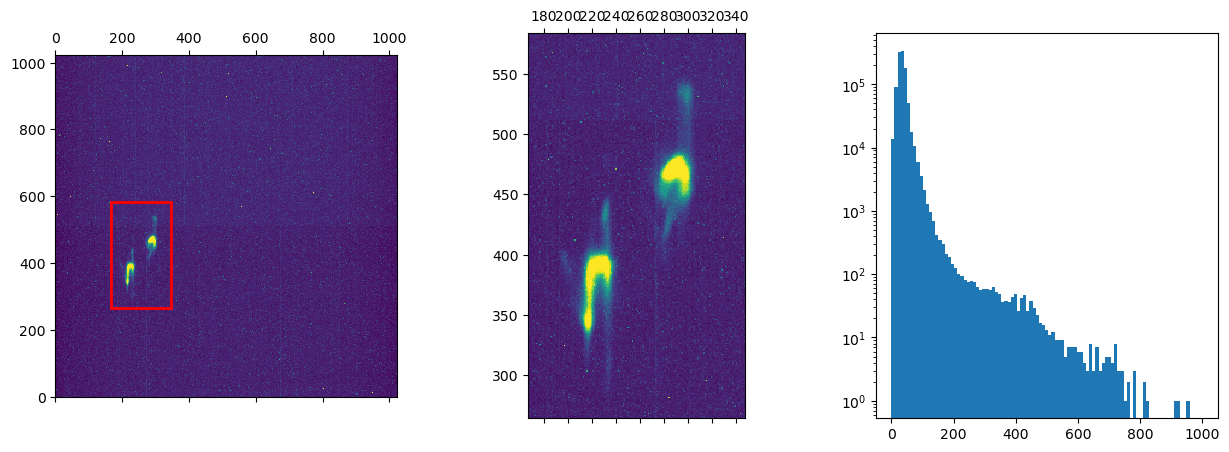

Showing 'ok' shot #4 at time index 272:


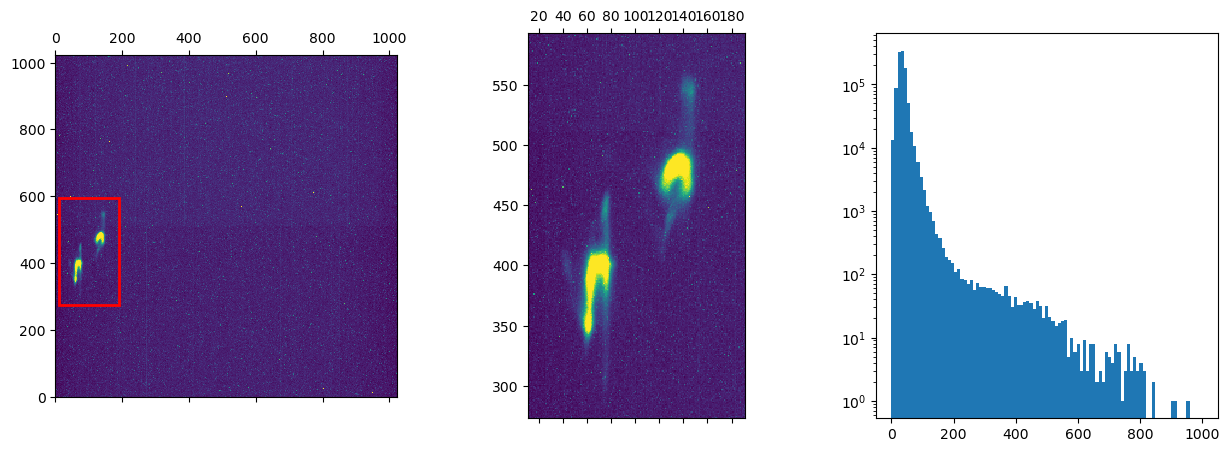

In [19]:
# Examine a few more events

n_shots_show = 3

print(f"Looping through the next {n_shots_show} 'ok' events...")
for idx,(i,j,evt) in enumerate(xton.shot_iterator):
    print(f"Showing 'ok' shot #{i+1} at time index {j}:")

    # Get & show event
    xton.set_current_event(evt)
    xton.show_current_frame()

    # continue?
    if idx>=n_shots_show-1:
        break

Looping through the first 3 'ok' events...
Showing 'ok' shot #1 at time index 269:


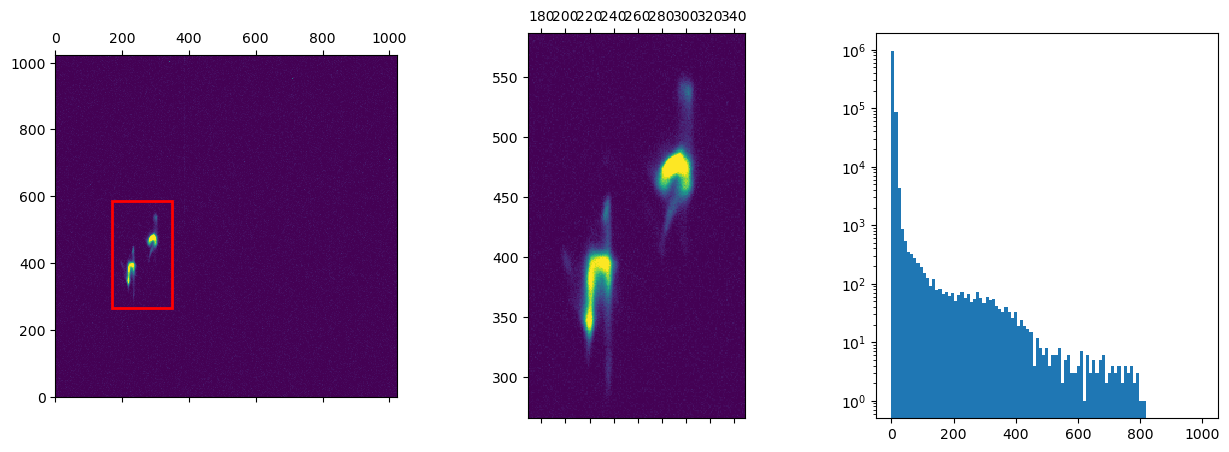

Showing 'ok' shot #2 at time index 270:


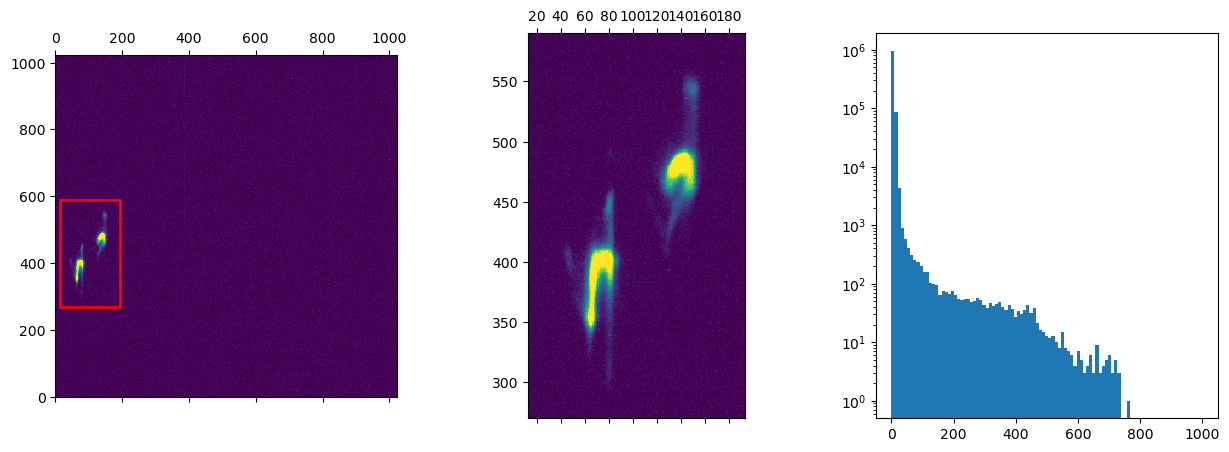

Showing 'ok' shot #3 at time index 271:


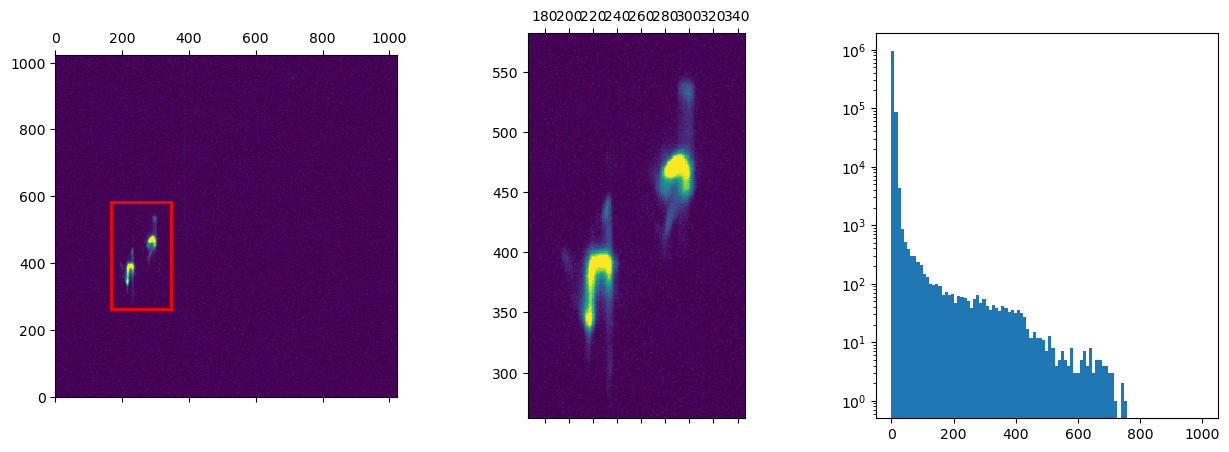

In [20]:
# Background subtraction

# Set dark ref
#xton.set_darkreference(xtdr)

# Examine dark ref subtracted data
xton.reset_shot_iterator()
n_shots_show = 3
print(f"Looping through the first {n_shots_show} 'ok' events...")
for idx,(i,j,evt) in enumerate(xton.shot_iterator):
    print(f"Showing 'ok' shot #{i+1} at time index {j}:")

    # Get & show event
    xton.set_current_event(evt)
    xton.show_current_frame(preprocess='bksb')

    # continue?
    if idx>=n_shots_show-1:
        break

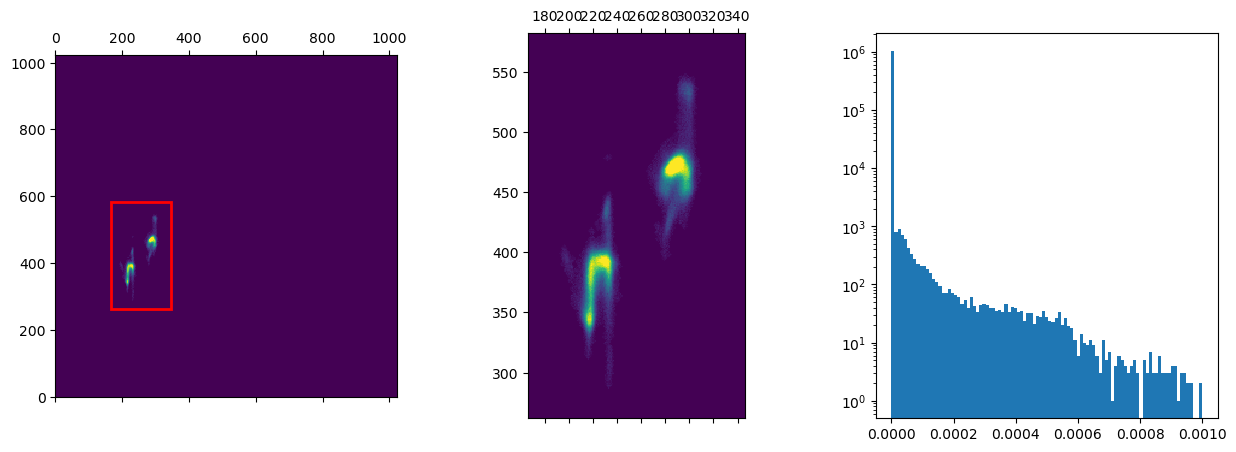

In [21]:
# Denoise

xton.show_frame(
    frame = xton.get_frame_denoised_current(
        nstd=1,                              # auto updates default params
        close=2
    ),
    vrange=(0,6e-4),                         # update intensity display range;
    bins=np.linspace(0,1e-3,100),            # denoising also normalizes total image intensity to 1
)

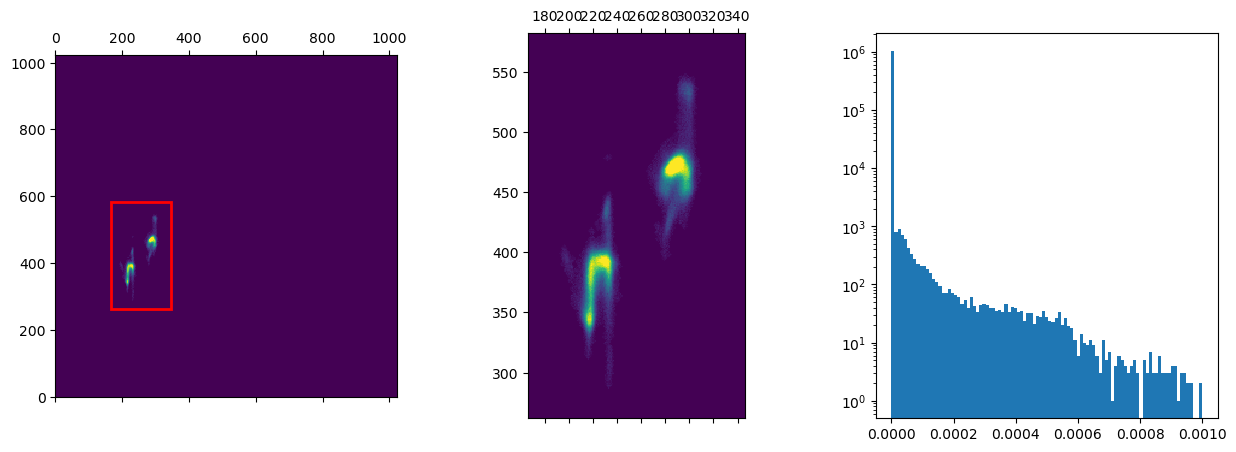

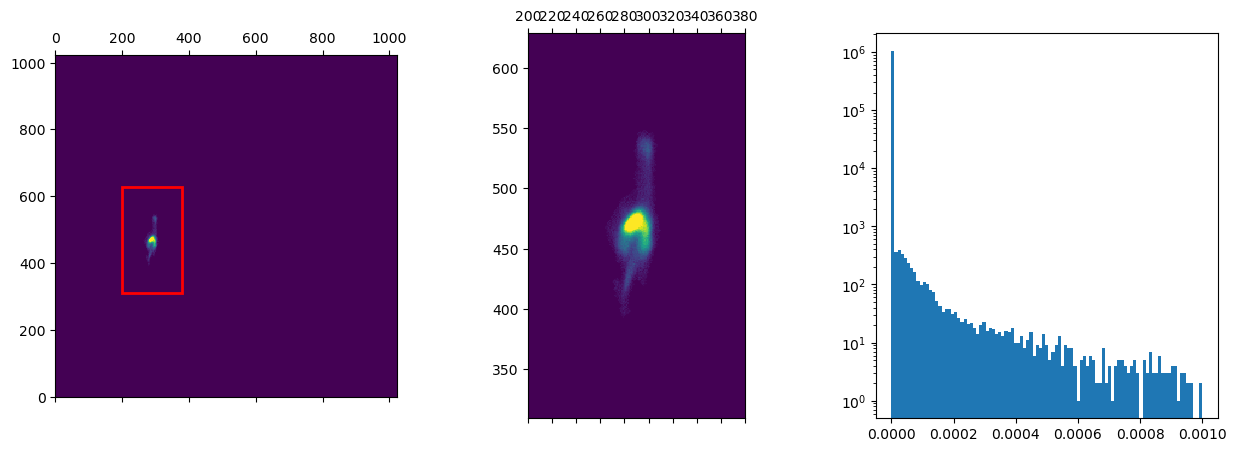

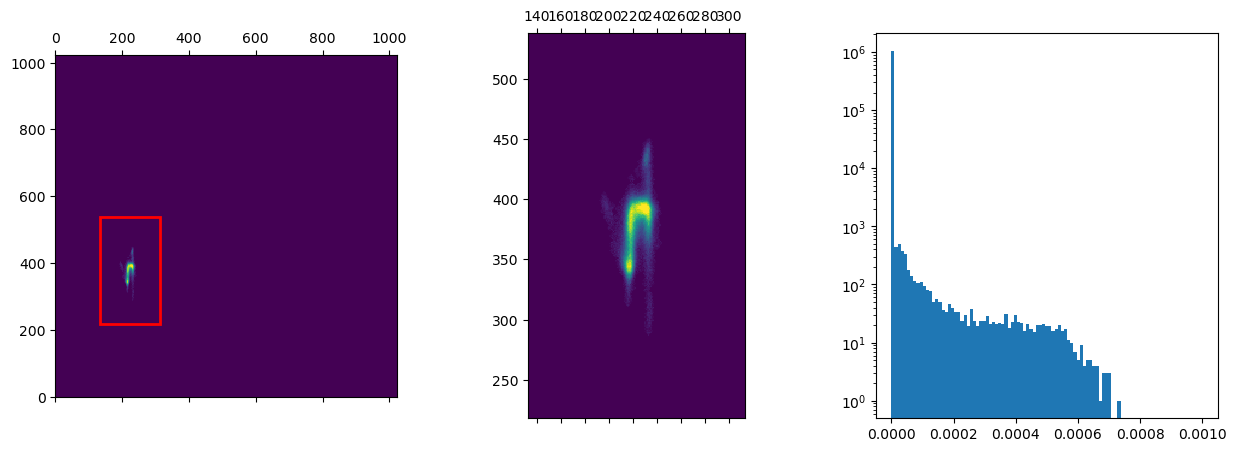

In [22]:
# Split images

# Get a denoised frame & split its pulses
im = xton.get_frame_denoised_current()
ims,ok = xton.split_frame(im)
assert(ok), "Failed to split image frame"

# Show
for image in (im,ims[0],ims[1]):   # Original image, pulse 1, and pulse 2
    xton.show_frame(image)

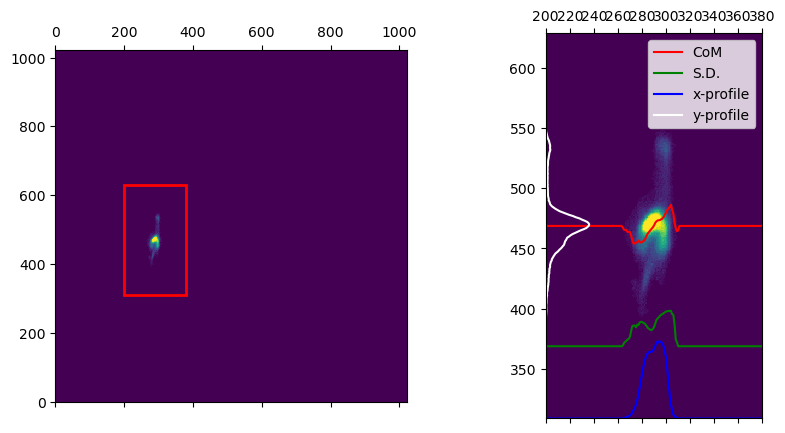

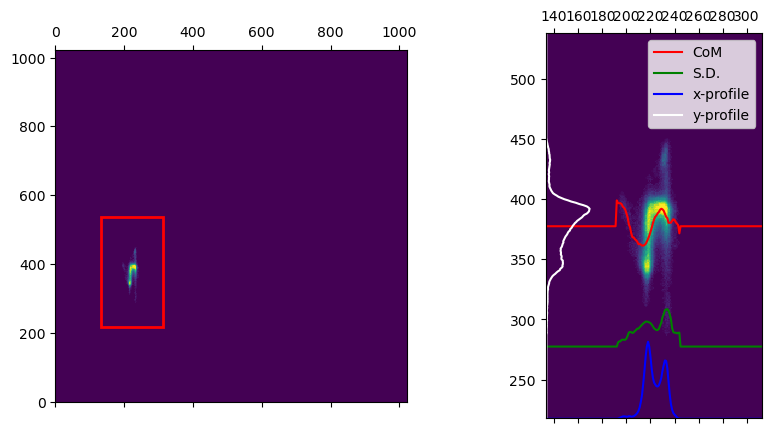

In [23]:
# Get image statistics

frame1,frame2 = ims[0],ims[1]
imageStats1 = xton.get_pulse_statistics(frame1)
imageStats2 = xton.get_pulse_statistics(frame2)

# Show
xton.show_frame_statistics(
    frame1,
    imageStats1,
)
xton.show_frame_statistics(
    frame2,
    imageStats2,
)

## Get full lasing-on data run image statistics

In [24]:
xton.get_shot_by_shot_statistics( n_pulses=2, _n_shots_max=1000 )

Calculating shot-by-shot statistics...:   0%|          | 0/1000 [00:00<?, ?it/s]

/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:1381: UserWarning: Hardcoded calibrations are not yet calculated - returning uncalibrated axes!
  ok = 1
/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:1527: RuntimeWarning: invalid value encountered in scalar divide
  y = np.sum(yy*ar)/m
/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:1528: RuntimeWarning: invalid value encountered in scalar divide
  return np.array([y,x])


Done. Calculated statistics for 911 'good' shots.
Setting shot iterator to traverse good shots only.


/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:649: UserWarning: 'Good' shots have not yet been determined during initial pass; using 'ok' shot iterator.
  warnings.warn("'Good' shots have not yet been determined during initial pass; using 'ok' shot iterator.")


-------------------------------
Showing usable shot #1:
-------------------------------


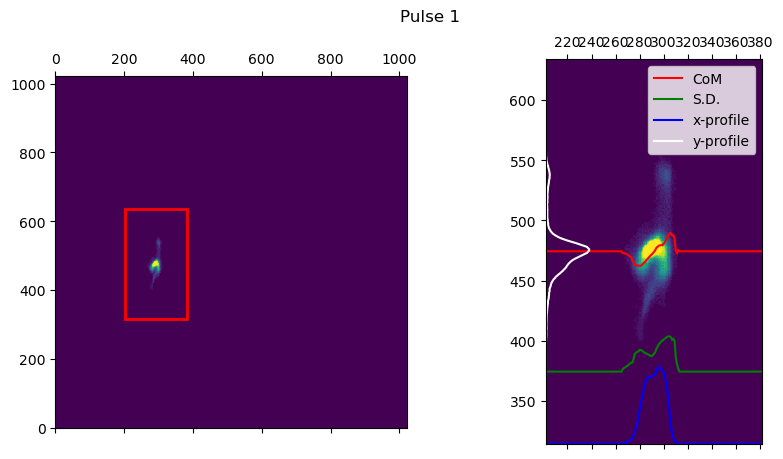

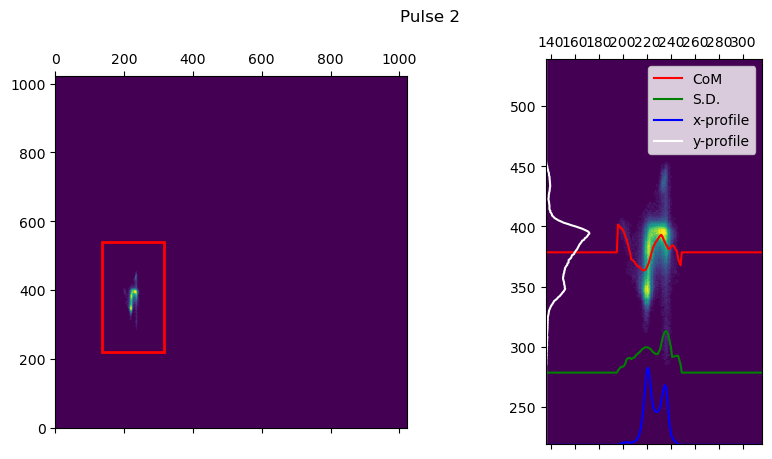

-------------------------------
Showing usable shot #21:
-------------------------------


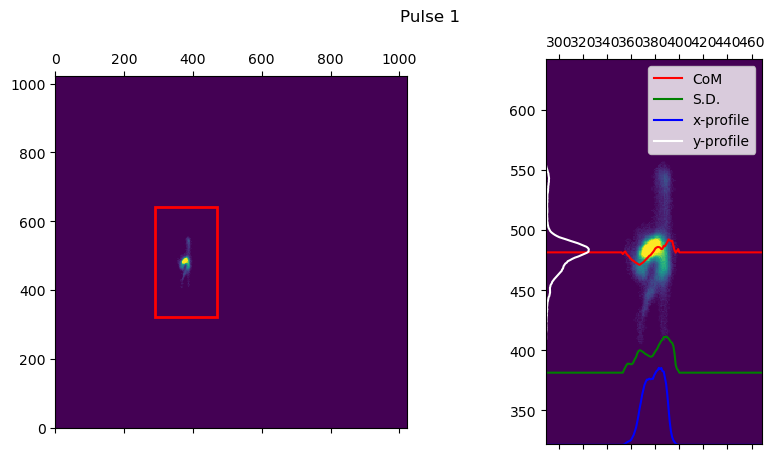

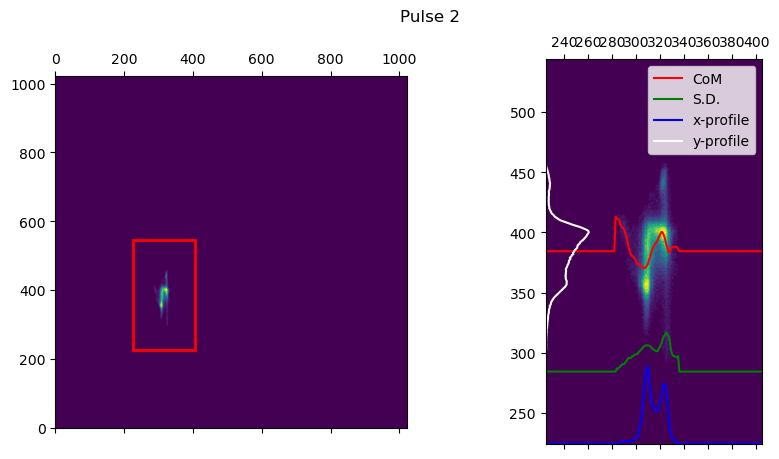

-------------------------------
Showing usable shot #51:
-------------------------------


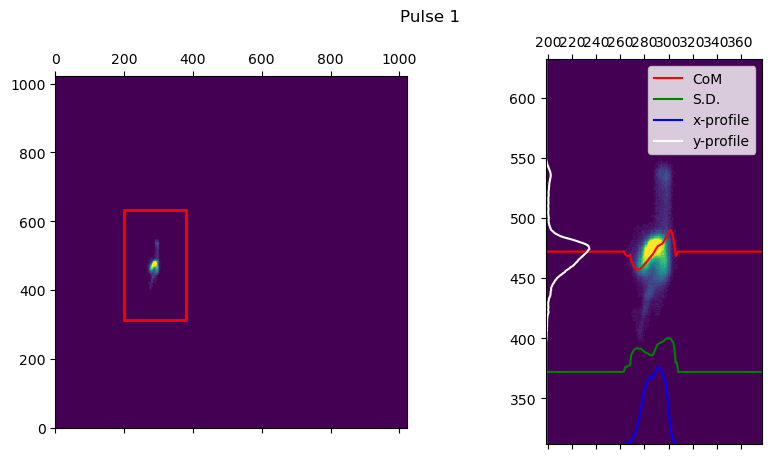

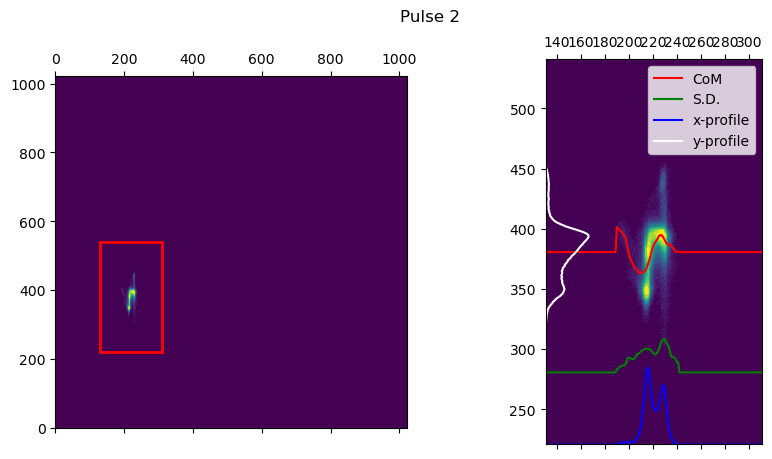

-------------------------------
Showing usable shot #90:
-------------------------------


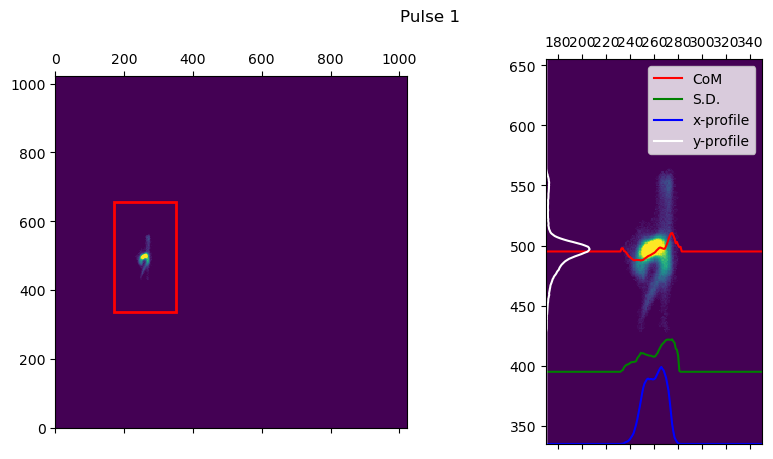

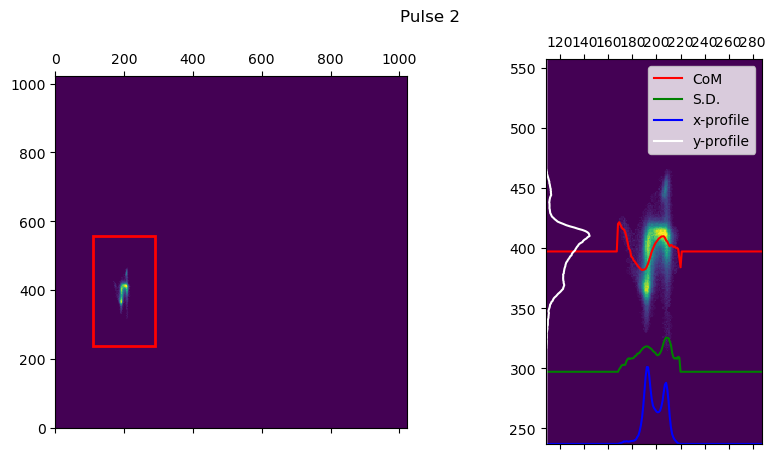

In [26]:
# Show a few shots & their pulse statistics

#for i in [0,200,500,910]:       # select a few shots
for i in [0,20,50,89]:          # select a few shots
    print("-------------------------------")
    print(f"Showing usable shot #{i+1}:")
    print("-------------------------------")
    xton.show_pulse_statistics(
        i,
        n_pulses=2,
    )

## Reconstruct single-shot power profiles

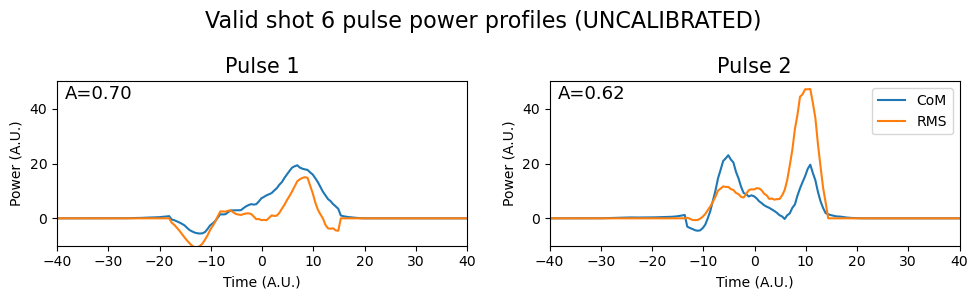

In [27]:
# Get a power profile

idx = 5

recon = xton.get_single_shot_power_profile(idx)
xton.show_pulse_power_reconstruction(
    recon,
    xlim=[-40,40],
    ylim=[-10,50],
    title=f'Valid shot {idx+1} pulse power profiles (UNCALIBRATED)',
)

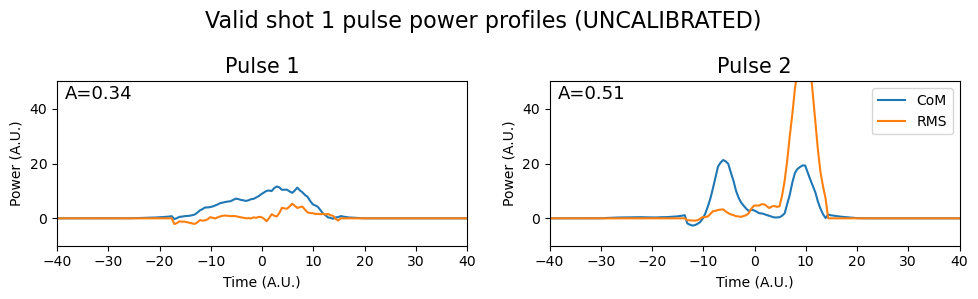

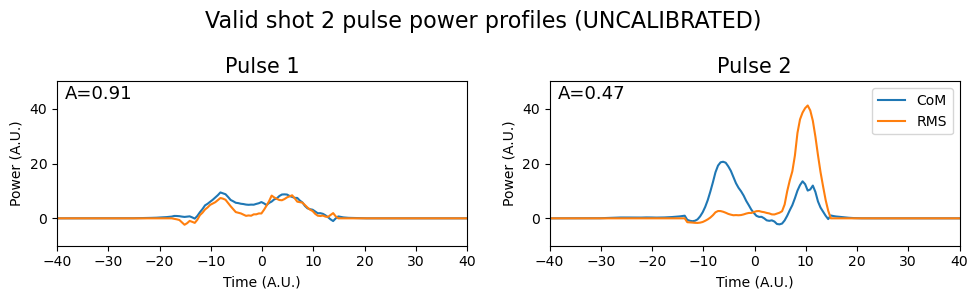

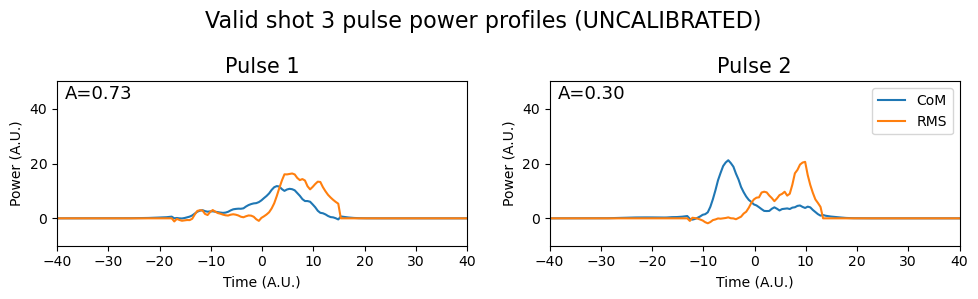

In [28]:
# Show a few pulses

for idx in np.arange(3):

    recon = xton.get_single_shot_power_profile(idx)
    xton.show_pulse_power_reconstruction(
        recon,
        xlim=[-40,40],
        ylim=[-10,50],
        title=f'Valid shot {idx+1} pulse power profiles (UNCALIBRATED)',
    )

## Reconstruct power profiles

In [29]:
xton.get_power_profiles()

Reconstructing power profiles:   0%|          | 0/911 [00:00<?, ?it/s]

Calculating reconstruction agreement statistics:   0%|          | 0/201 [00:00<?, ?it/s]

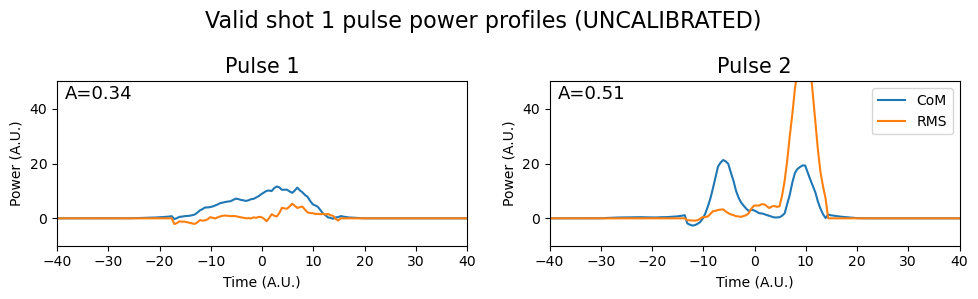

In [30]:
idx = 0

xton.show_power_profiles(
    idx,
    xlim=[-40,40],
    ylim=[-10,50],
    title=f'Valid shot {idx+1} pulse power profiles (UNCALIBRATED)',
)

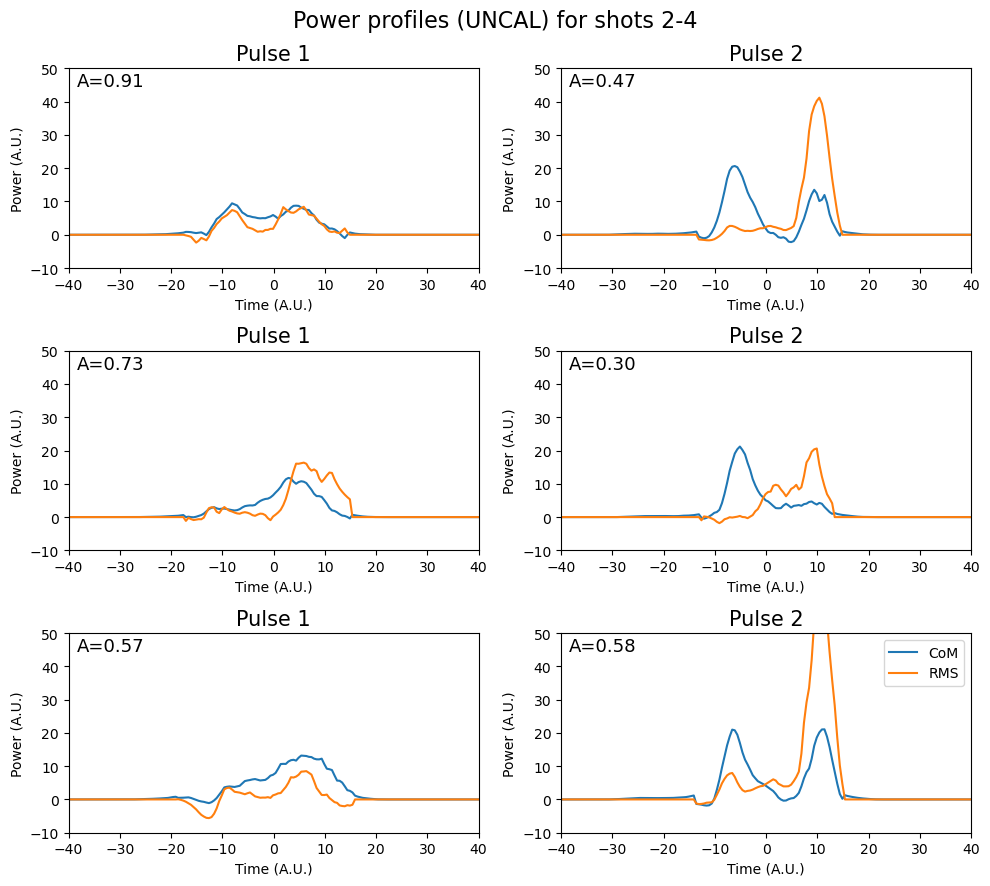

In [31]:
idx_first_shot = 1
n_shots_plot = 3

xton.show_power_profile_group(
    np.arange(idx_first_shot,idx_first_shot+n_shots_plot),
    xlim=[-40,40],
    ylim=[-10,50],
    title=f'Power profiles (UNCAL) for shots {idx_first_shot+1}-{idx_first_shot+n_shots_plot}'
)

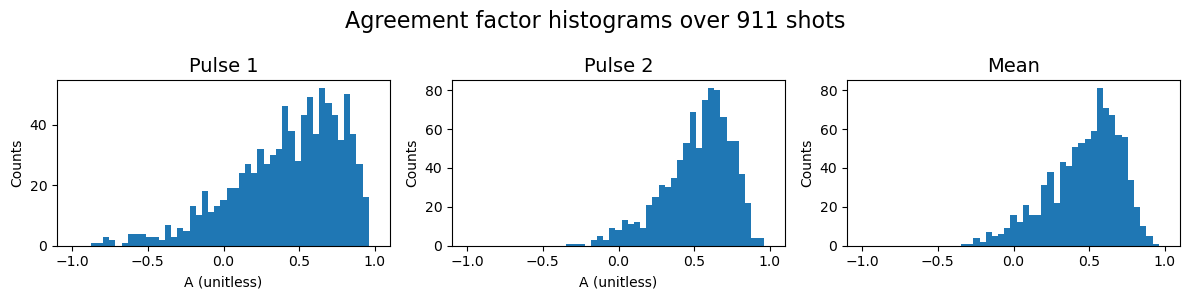

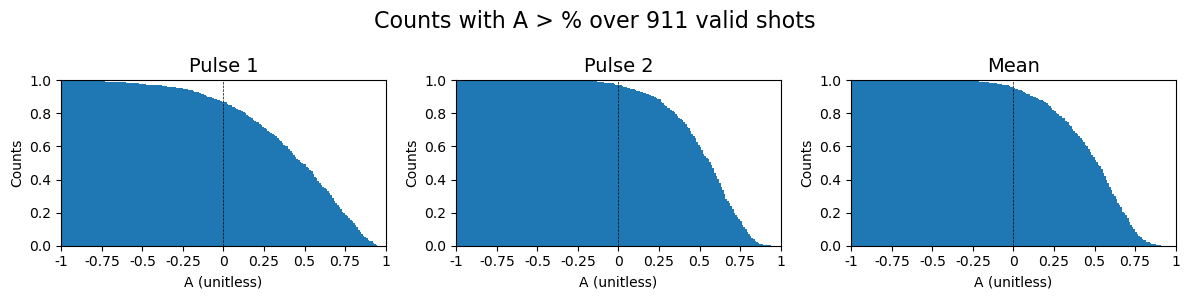

In [32]:
xton.show_agreement_histograms()
xton.show_cumulative_histograms()

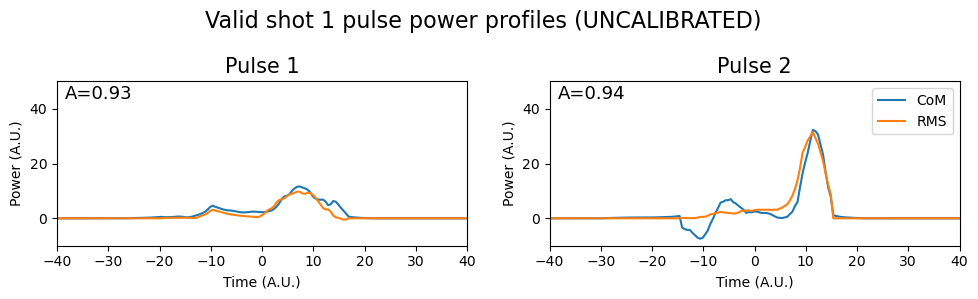

In [33]:
xton.show_power_profiles(
    xton.agreement_stats['inds_ordered_means'][0],
    xlim=[-40,40],
    ylim=[-10,50],
    title=f'Valid shot {idx+1} pulse power profiles (UNCALIBRATED)',
)

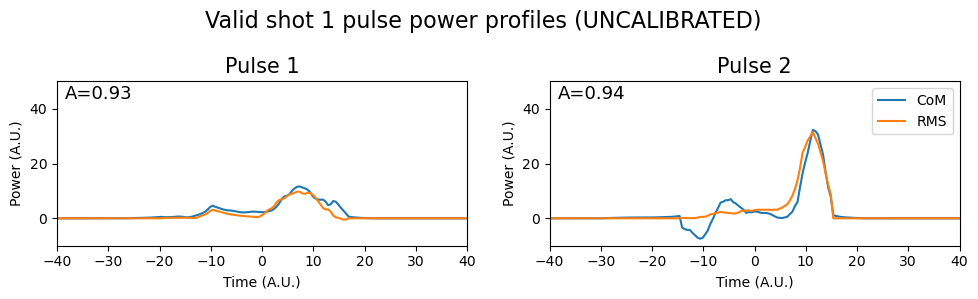

In [34]:
xton.show_best_power_profiles(
    0,
    xlim=[-40,40],
    ylim=[-10,50],
    title=f'Valid shot {idx+1} pulse power profiles (UNCALIBRATED)',
)

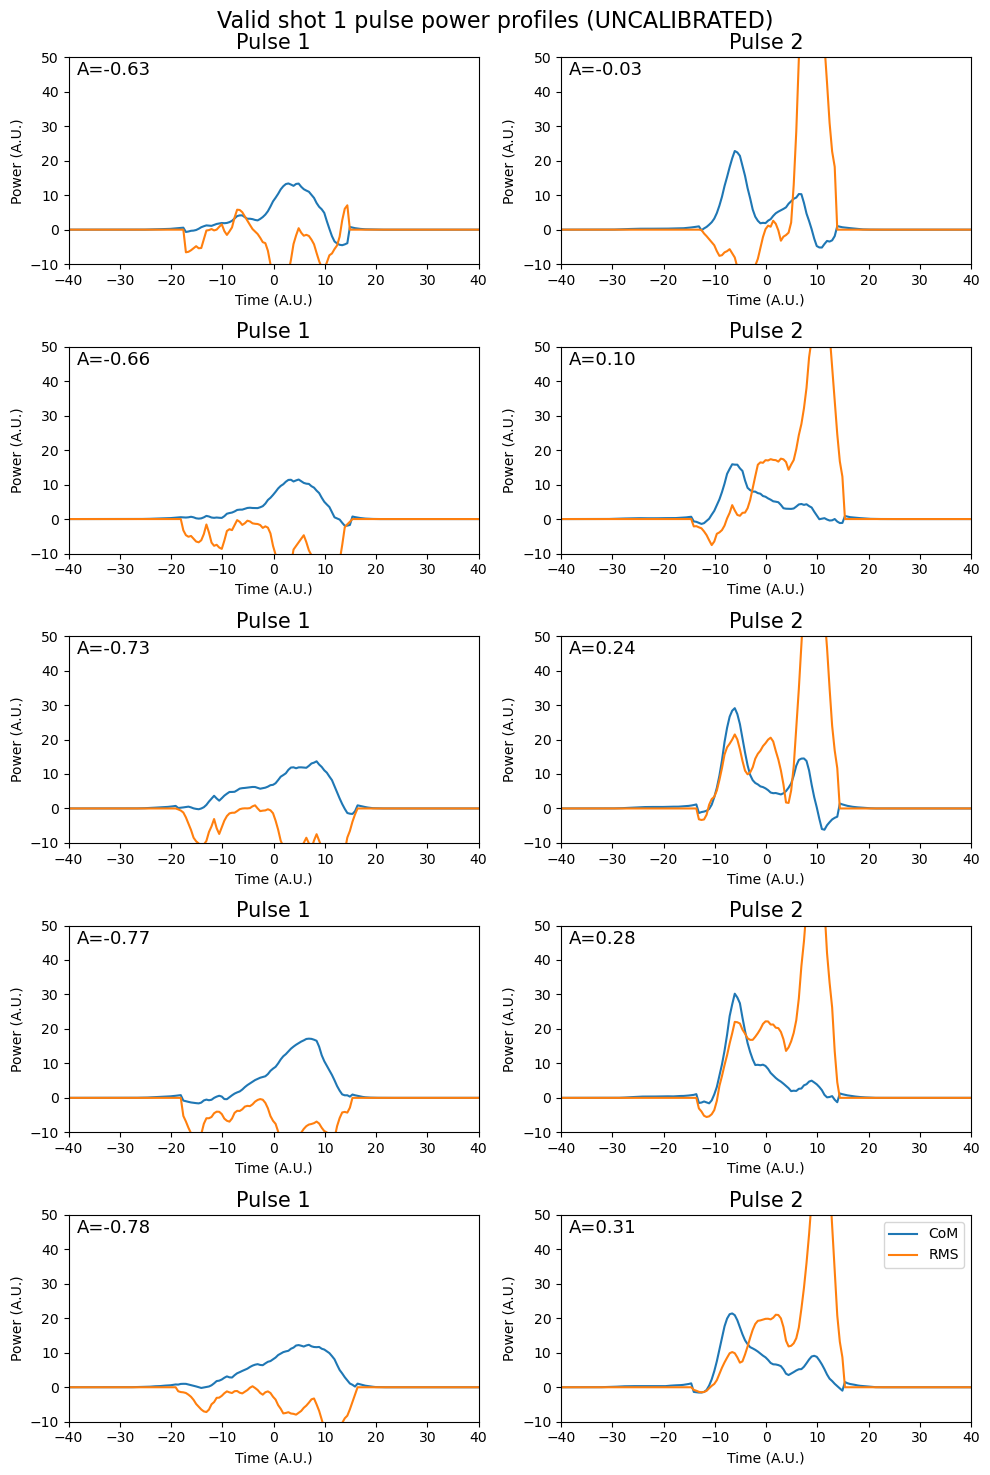

In [35]:
xton.show_worst_power_profile_group(
    np.arange(5),
    xlim=[-40,40],
    ylim=[-10,50],
    title=f'Valid shot {idx+1} pulse power profiles (UNCALIBRATED)',
)